# Plotting results MH harmonic

In [10]:
import os, sys, time
import argparse
from collections import namedtuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from getdist import plots, MCSamples
import getdist
import scipy as sp
import healpy as hp
import astropy.io.fits as fits
import camb
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax_healpy as jhp
import jax.random as random
import toml
import numpyro
from functools import partial
import micmac
from micmac import *
from fgbuster.observation_helpers import *
from fgbuster import (CMB, Dust, Synchrotron,
                      basic_comp_sep,
                      get_observation, get_instrument)

from jax import config
current_path = os.path.abspath('')
sys.path.append(current_path)
sys.path.append(os.path.dirname(os.path.dirname(current_path))+'/tutorials/')

config.update("jax_enable_x64", True)

In [11]:
path_home_test_playground = os.path.dirname(current_path) + '/'

In [12]:
working_directory_path = os.path.abspath('') + '/'
directory_save_file = working_directory_path + 'save_directory/'
directory_toml_file = working_directory_path + 'main_params/'
directory_additional_params = working_directory_path + 'additional_params/'

# path_toml_file = directory_toml_file + 'test_full_chain_v1a.toml'
# path_toml_file = directory_toml_file + 'test_classical_chain_v1a.toml'


In [13]:
num_jobs = 1


file_ver_ns0 = 'corr_fullsky_LB_d0s0_r0_v1bec24_{}_{}'
path_additional_params_ns0 = directory_additional_params + 'add_corr_fullky_LB_d0s0_v1bec.toml'

file_ver_ns1 = 'corr_fullsky_LB_d0s0_r0_v1bec24_{}_{}'
path_additional_params_ns1 = directory_additional_params + 'add_corr_fullky_LB_d0s0_v1bec.toml'

list_file_ver = [file_ver_ns0, file_ver_ns1]
list_path_additional_params = [path_additional_params_ns0, path_additional_params_ns1]

In [14]:
list_ns = []

for path_additional_param in list_path_additional_params:
    list_ns.append(int(toml.load(path_additional_param)['name_file_spv'][-6]))

In [16]:
path_additional_params = list_path_additional_params[0]

In [17]:
with open(path_additional_params) as f:
    dictionary_additional_parameters = toml.load(f)
f.close()

directory_mask = dictionary_additional_parameters['directory_mask']
reduction_noise = dictionary_additional_parameters['reduction_noise']
# factor_Fisher = dictionary_additional_parameters['factor_Fisher']
relative_treshold = dictionary_additional_parameters['relative_treshold']
use_treshold = dictionary_additional_parameters['use_treshold']
# sigma_gap = dictionary_additional_parameters['sigma_gap']
fgs_model = dictionary_additional_parameters['fgs_model']
if fgs_model == 'customized_parametric':
    # additional params necessary to build the parametric customized model
    fgs_model_init = dictionary_additional_parameters['fgs_model_init']
    nside_spv_model = dictionary_additional_parameters['nside_spv_model']
    print('--> using customized parametric fgs model, built from ', 
          fgs_model_init, 'with spv spectral params: ', nside_spv_model)
elif fgs_model == 'customized_nonparametric':
    # additional params necessary to build the non-parametric customized model
    fgs_model_init = dictionary_additional_parameters['fgs_model_init']
    nside_spv_model = dictionary_additional_parameters['nside_spv_model']
    idx_ref_freq = dictionary_additional_parameters['idx_ref_freq']
    print('--> using customized non-parametric fgs model, built from ', 
          fgs_model_init, 'with spv scaling laws: ', nside_spv_model)
# initial_guess_r = dictionary_additional_parameters['initial_guess_r']
# use_nhits = dictionary_additional_parameters['use_nhits']
name_mask = dictionary_additional_parameters['name_mask']
# use_mask = dictionary_additional_parameters['use_mask']
name_toml = dictionary_additional_parameters['name_toml']
# name_file_spv = dictionary_additional_parameters['name_file_spv']
print("Using toml file: ", name_toml)

Using toml file:  corr_fullsky_LB_r0_v1c.toml


In [18]:
path_toml_file = directory_toml_file + name_toml

In [19]:
MICMAC_sampler_obj = micmac.create_MICMAC_sampler_from_toml_file(path_toml_file)


No spatial variability case



>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f0
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default: None
      b8
        default: None
      b9
        default: None
      b10
        default: None
      b11
        default: None
      b12
        default: None
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default: None
      b8
        default: None
      b9
        default: None
      b10
        default: None
      b11
        default: None
      b12
        default: None

>>> Tree of spv config after filling the missing val

In [20]:
initial_freq_maps = []
input_cmb_maps = []
input_noise_map = []
all_eta_maps = []
all_s_c_WF_maps = []
all_s_c_fluct_maps = []
all_s_c_samples = []
all_s_c_spectra = []
all_r_samples = []
all_cell_samples = []
all_params_mixing_matrix_samples = []

job = 0
num_jobs = 1

for i in range(len(list_file_ver)):
    file_ver = list_file_ver[i]
    initial_freq_maps_path = directory_save_file+file_ver.format(job,num_jobs)+'_initial_data.npy'
    initial_freq_maps.append(np.load(initial_freq_maps_path))

    initial_cmb_maps_path = directory_save_file+file_ver.format(job,num_jobs)+'_initial_cmb_data.npy'
    input_cmb_maps.append(np.load(initial_cmb_maps_path))

    initial_noise_map_path = directory_save_file+file_ver.format(job,num_jobs)+'_initial_noise_data.npy'
    input_noise_map.append(np.load(initial_noise_map_path))

    if MICMAC_sampler_obj.sample_r_Metropolis:
        all_r_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_r_samples.npy'
        all_r_samples.append(np.load(all_r_samples_path))
    elif MICMAC_sampler_obj.sample_C_inv_Wishart:
        all_cell_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_cell_samples.npy'
        all_cell_samples.append(np.load(all_cell_samples_path))

    all_params_mixing_matrix_samples_path = directory_save_file+file_ver.format(job,num_jobs)+'_all_params_mixing_matrix_samples.npy'
    all_params_mixing_matrix_samples.append(np.load(all_params_mixing_matrix_samples_path))

initial_freq_maps = np.array(initial_freq_maps)
input_cmb_maps = np.array(input_cmb_maps)
input_noise_map = np.array(input_noise_map)

if MICMAC_sampler_obj.sample_r_Metropolis:
    # all_r_samples = np.array(all_r_samples)
    MICMAC_all_r_samples = all_r_samples
elif MICMAC_sampler_obj.sample_C_inv_Wishart:
    all_cell_samples = np.array(all_cell_samples)

# all_params_mixing_matrix_samples = np.array(all_params_mixing_matrix_samples)
MICMAC_all_params_mixing_matrix_samples = all_params_mixing_matrix_samples

In [21]:
input_freq_maps = initial_freq_maps[0]

In [22]:
len_pos_special_freqs = len(MICMAC_sampler_obj.pos_special_freqs)

In [23]:
_, _, theoretical_red_cov_r0_total, theoretical_red_cov_r1_tensor = MICMAC_sampler_obj.generate_input_freq_maps_from_fgs(np.zeros((MICMAC_sampler_obj.n_frequencies,
                                                                                                                                    MICMAC_sampler_obj.nstokes,
                                                                                                                                    MICMAC_sampler_obj.n_pix,)), 
                                                                                                                            return_only_freq_maps=False)

c_ell_true_CMB = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total + MICMAC_sampler_obj.r_true*theoretical_red_cov_r1_tensor)
c_ell_CMB_r2 = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total + 0.01*theoretical_red_cov_r1_tensor)
c_ell_lensing = micmac.get_c_ells_from_red_covariance_matrix_JAX(theoretical_red_cov_r0_total)

Calculating spectra from CAMB !
Calculating spectra from CAMB !


In [24]:
if MICMAC_sampler_obj.instrument_name != 'customized_instrument': ## TODO: Improve a bit this part
        instrument = get_instrument(MICMAC_sampler_obj.instrument_name)
else:
    with open(path_toml_file) as f:
        dictionary_toml = toml.load(f)
    f.close()
    instrument = micmac.get_instr(MICMAC_sampler_obj.frequency_array, dictionary_toml['depth_p'])


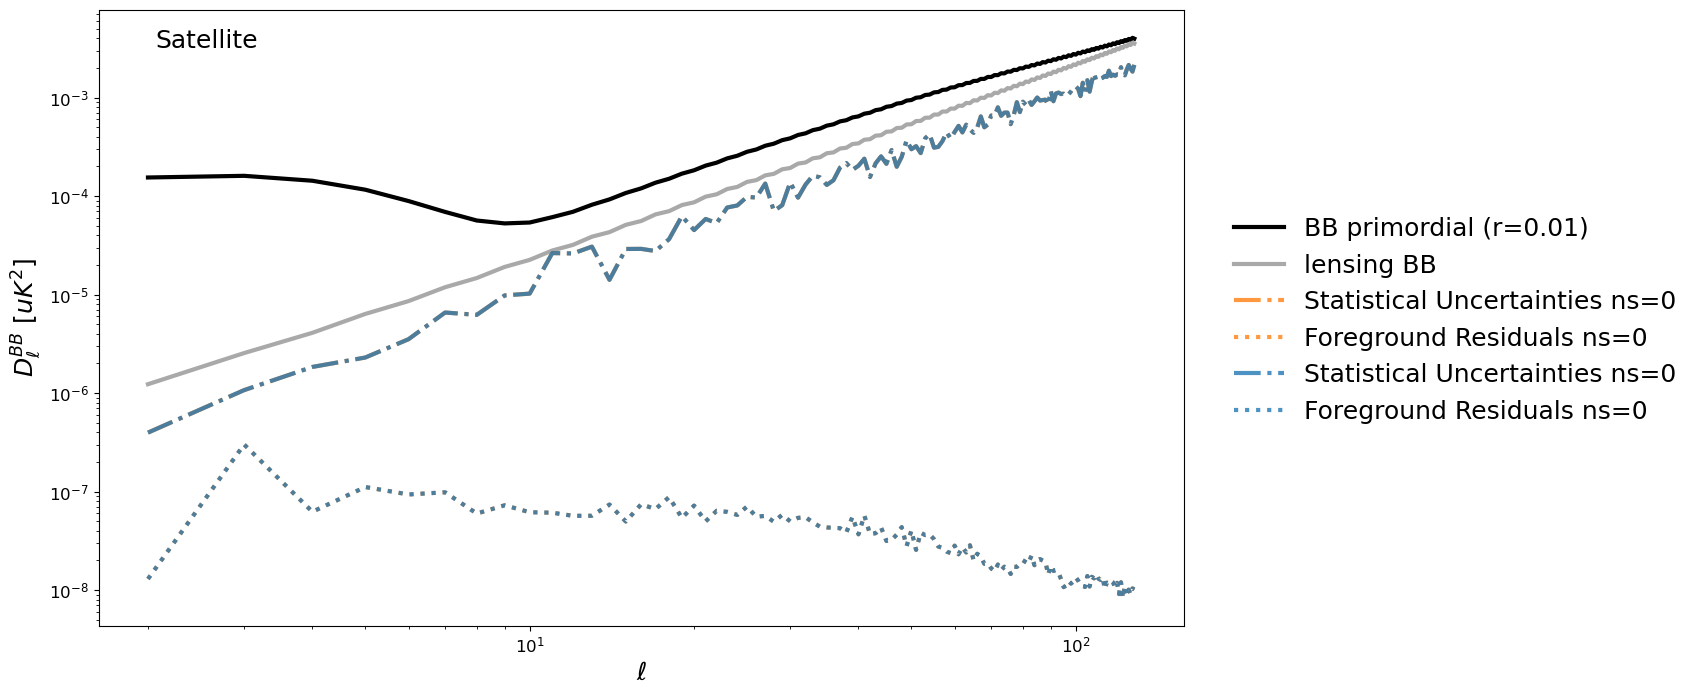

In [27]:
# Residuals power spectrum

# Set-up burn-in
burnin = 8000 #8000

colorstyle_list = ['tab:orange','tab:blue','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']

indices_polar = np.array([1,2,4])

linewidth_plots = 3

# fig = plt.figure(figsize=(14,8))
fig, axes = plt.subplots(figsize=(14,8))

# lmin_LB = 2
# lmin_S0 = 30 - lmin_LB

ell_array = np.arange(MICMAC_sampler_obj.lmin, MICMAC_sampler_obj.lmax+1)

factor_ell = (ell_array*(ell_array+1))/(2*np.pi)

plt.plot(ell_array, c_ell_CMB_r2[1,:]*factor_ell, 'k', linewidth=linewidth_plots, label='BB primordial (r=0.01)')
plt.plot(ell_array, c_ell_lensing[1,:]*factor_ell, color='darkgray', linewidth=linewidth_plots, label='lensing BB')


# mean_params_Pixel = MICMAC_all_params_mixing_matrix_samples[0,-burnin:].mean(axis=0)

mean_params_list = [MICMAC_all_params_mixing_matrix_samples[i][-burnin:].mean(axis=0) for i in range(len(list_ns))]

# MICMAC_sampler_obj = MICMAC_sampler_obj_list[i]
# freq_inverse_noise = freq_inverse_noise_list[i]
freq_inverse_noise = micmac.get_noise_covar_extended(np.array(instrument['depth_p']), MICMAC_sampler_obj.nside)
# f_sky = f_sky_list[i]

for i in range(len(mean_params_list)):
    mean_mixing_matrix = MICMAC_sampler_obj.get_B_from_params(mean_params_list[i])
    recovered_CMB_Wd_mean = micmac.get_Wd(freq_inverse_noise, 
                                            mean_mixing_matrix, 
                                            (initial_freq_maps[0]-input_cmb_maps[0]-input_noise_map[0])*MICMAC_sampler_obj.mask, 
                                            jax_use=False)[0, :, :]
    recovered_res_wo_CMB_mean = micmac.get_Wd(freq_inverse_noise, 
                                                mean_mixing_matrix, 
                                                initial_freq_maps[0]*MICMAC_sampler_obj.mask, 
                                                jax_use=False)[0, :, :] - input_cmb_maps[0][0]*MICMAC_sampler_obj.mask
    recovered_CMB_Wd_mean_extended = np.vstack([np.zeros_like(recovered_CMB_Wd_mean[0]), recovered_CMB_Wd_mean])
    c_ells_recovered_CMB_Wd_mean = hp.anafast(recovered_CMB_Wd_mean_extended, lmax=MICMAC_sampler_obj.lmax, iter=MICMAC_sampler_obj.n_iter)[2,MICMAC_sampler_obj.lmin:]#/f_sky
    recovered_res_wo_CMB_mean_extended = np.vstack([np.zeros_like(recovered_res_wo_CMB_mean[0]), recovered_res_wo_CMB_mean])
    c_ells_recovered_res_wo_CMB_mean = hp.anafast(recovered_res_wo_CMB_mean_extended, lmax=MICMAC_sampler_obj.lmax, iter=MICMAC_sampler_obj.n_iter)[2,MICMAC_sampler_obj.lmin:]#/f_sky

    ell_array = np.arange(c_ells_recovered_CMB_Wd_mean.shape[-1])+MICMAC_sampler_obj.lmin

    factor_ell = (ell_array*(ell_array+1))/(2*np.pi)


    # label_Stat_res = f"{MICMAC_sampler_obj.instrument_name} r={list_r_values[i]} ; Statistical Residuals"
    label_Stat_res = f"Statistical Uncertainties ns={list_ns[i]}"
    label_Syst_res = f'Foreground Residuals ns={list_ns[i]}'

    linestyle_dashdotted = '-.'
    # if list_r_values[i] == 0.01:
    #     linestyle_dashdotted = (0, (3, 1, 1, 1, 1, 1))
    plt.plot(ell_array, 
                (c_ells_recovered_res_wo_CMB_mean-c_ells_recovered_CMB_Wd_mean)*factor_ell,
                linestyle=linestyle_dashdotted,
                linewidth=linewidth_plots,
                color=colorstyle_list[i], 
                label=label_Stat_res, alpha=.8)

    linestyle_dotted = ':'
    # if list_r_values[i] == 0.01:
    #     linestyle_dotted = (0, (1, 1))
    plt.plot(ell_array, 
                c_ells_recovered_CMB_Wd_mean*factor_ell, 
                linestyle=linestyle_dotted,
                linewidth=linewidth_plots, 
                color=colorstyle_list[i], 
                label=label_Syst_res, alpha=.8)

if MICMAC_sampler_obj.instrument_name == 'LiteBIRD':
    plt.loglog()
else:
    plt.yscale('log')
# if i == 2:
plt.ylabel("$D^{BB}_\ell$ [$uK^2$]",fontsize=18)
plt.xlabel(r"$\ell$",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)

# plt.text(.13, .97, 'Satellite', 
#                         horizontalalignment='center', 
#                         verticalalignment='center', 
#                         fontsize=18, 
#                         transform=axes['a'].transAxes)
plt.text(.1, .95, 'Satellite', 
                        horizontalalignment='center', 
                        verticalalignment='center', 
                        fontsize=18, 
                        transform=axes.transAxes)
# handles_a, labels_a = axes['a'].get_legend_handles_labels()
# handles_b, labels_b = axes['b'].get_legend_handles_labels()
# fig.legend(handles_b+handles_a, labels_b+labels_a, bbox_to_anchor=(.73, .45), loc='upper center', prop={'size': 18}, frameon=False)

# plt.legend(bbox_to_anchor=(.73, .7), loc='upper center', prop={'size': 18}, frameon=False)
plt.legend(bbox_to_anchor=(1.25, .7), loc='upper center', prop={'size': 18}, frameon=False)
plt.show()
